# CEDAR Classification Notebook

Trains a signature classifier on the CEDAR-Buffalo dataset. Mirrors the
BHSig-Hindi classification notebook in architecture and training recipe
but adapts the data pipeline to CEDAR's `full_org/` + `full_forg/`
structure.

### Tasks and knobs

Five knobs at the top of the notebook:

- **`TASK`**: `"writer"` (N-way writer classification, genuine only) or
  `"forgery"` (2-way genuine vs. forgery).
- **`NUM_CLASSES_TO_USE`** (writer task only): 2, 10, or `None` (all 55).
- **`BACKBONE`**: `"custom"` or `"resnet18"`.
- **`PREPROCESS_MODE`**: `"standard"` (grayscale + invert + resize) or
  `"binarized"` (adds Otsu thresholding to strip paper texture).
- **`FORGERY_SPLIT`** (forgery task only): `"writer_dependent"` (same
  writers in all splits) or `"writer_independent"` (10 writers held out
  entirely for test).

### Why the preprocess knobs exist

An earlier run with `TASK="forgery", BACKBONE="resnet18", PREPROCESS_MODE="standard"`
scored 100% test accuracy -- far above published CEDAR benchmarks
(~80-95%). Visual inspection showed genuine signatures were scanned on
textured paper with visible ruled-paper guide lines, while forgeries were
on clean white paper. The ResNet-18 was almost certainly exploiting this
acquisition artifact rather than learning stroke-level forgery detection.

`PREPROCESS_MODE="binarized"` applies Otsu thresholding per-image,
collapsing all pixels to pure black (ink) or pure white (background).
This removes the background cue and forces the model to look at stroke
shape.

`FORGERY_SPLIT="writer_independent"` holds out 10 writers entirely. The
test set contains only signatures from writers the model never trained
on, so per-writer memorization cannot contribute to the score.

## Imports

In [1]:
import os
import re
import copy
import json
import time
import random
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import accuracy_score, confusion_matrix

## Seed and device

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU name:", torch.cuda.get_device_name(0))

Device: cuda
GPU name: NVIDIA GeForce RTX 4070 Laptop GPU


## Experiment configuration

Change these knobs between runs.

In [ ]:
# ---- KNOBS TO CHANGE BETWEEN RUNS ----
TASK = "forgery"                          # "writer" or "forgery"
NUM_CLASSES_TO_USE = 2                    # 2, 10, or None; ignored when TASK=="forgery"
BACKBONE = "resnet18"                     # "custom" or "resnet18"
PREPROCESS_MODE = "binarized"             # "standard" or "binarized"
FORGERY_SPLIT = "writer_dependent"      # "writer_dependent" or "writer_independent"; only used when TASK=="forgery"
# ---------------------------------------

CEDAR_DIR = Path("./CEDAR-Buffalo")
GENUINE_DIR = CEDAR_DIR / "full_org"
FORGERY_DIR = CEDAR_DIR / "full_forg"

BATCH_SIZE = 8
WEIGHT_DECAY = 1e-4

if BACKBONE == "resnet18":
    IMAGE_HEIGHT, IMAGE_WIDTH = 224, 224
    NORM_MEAN = [0.485, 0.456, 0.406]
    NORM_STD = [0.229, 0.224, 0.225]
    BACKBONE_LR = 3e-5
    HEAD_LR = 3e-4
elif BACKBONE == "custom":
    IMAGE_HEIGHT, IMAGE_WIDTH = 155, 220
    NORM_MEAN = [0.5]
    NORM_STD = [0.5]
    BACKBONE_LR = 3e-4
    HEAD_LR = 3e-4
else:
    raise ValueError(f"Unknown BACKBONE: {BACKBONE}")
# Gemini helped me with function.
# Epochs scale with task difficulty and dataset size.
if TASK == "forgery":
    NUM_EPOCHS = 30
elif NUM_CLASSES_TO_USE is None:
    NUM_EPOCHS = 50
elif NUM_CLASSES_TO_USE <= 2:
    NUM_EPOCHS = 20
else:
    NUM_EPOCHS = 30

RESULTS_DIR = Path("./cedar_run_results")
RESULTS_DIR.mkdir(exist_ok=True)

# Build a descriptive run tag.
tag_parts = []
if TASK == "forgery":
    tag_parts.append("forgery")
    tag_parts.append(FORGERY_SPLIT)
    effective_classes = 2
else:
    effective_classes = "all" if NUM_CLASSES_TO_USE is None else NUM_CLASSES_TO_USE
    tag_parts.append(f"writer_{effective_classes}")
tag_parts.append(BACKBONE)
if PREPROCESS_MODE != "standard":
    tag_parts.append(PREPROCESS_MODE)

RUN_TAG = "cedar_" + "_".join(str(p) for p in tag_parts)
RESULT_PATH = RESULTS_DIR / f"{RUN_TAG}.json"
CHECKPOINT_PATH = RESULTS_DIR / f"{RUN_TAG}_best.pt"

print(f"Task:            {TASK}")
print(f"Run tag:         {RUN_TAG}")
print(f"Backbone:        {BACKBONE}")
print(f"Preprocessing:   {PREPROCESS_MODE}")
if TASK == "forgery":
    print(f"Forgery split:   {FORGERY_SPLIT}")
print(f"Epochs:          {NUM_EPOCHS}")
print(f"Input:           {IMAGE_HEIGHT}x{IMAGE_WIDTH}")

Task:            forgery
Run tag:         cedar_forgery_writer_dependent_resnet18_binarized
Backbone:        resnet18
Preprocessing:   binarized
Forgery split:   writer_dependent
Epochs:          30
Input:           224x224


## Scan CEDAR images

In [4]:
_orig_re = re.compile(r"original_(\d+)_(\d+)\.png$", re.IGNORECASE)
_forg_re = re.compile(r"forgeries_(\d+)_(\d+)\.png$", re.IGNORECASE)


def index_signatures(folder, pattern):
    records = []
    for fname in sorted(os.listdir(folder)):
        m = pattern.search(fname)
        if m:
            w = int(m.group(1))
            s = int(m.group(2))
            records.append((w, s, folder / fname))
    return records


genuine_records = index_signatures(GENUINE_DIR, _orig_re)
forgery_records = index_signatures(FORGERY_DIR, _forg_re)

print(f"Genuine signatures: {len(genuine_records)}")
print(f"Forgery signatures: {len(forgery_records)}")

Genuine signatures: 1320
Forgery signatures: 1320


## Build the task-specific dataset

Three split strategies selected by `TASK` and `FORGERY_SPLIT`:

1. **Writer task:** partition each writer's genuine signatures by
   signature index (~14/5/5 train/val/test per writer).
2. **Forgery + writer-dependent:** use genuine and forgery. Partition by
   index. Same writers in all splits.
3. **Forgery + writer-independent:** hold out 10 writers entirely for
   test. Remaining 45 writers' signatures split by index for train/val.

In [5]:
class CedarDataset(Dataset):
    def __init__(self, records, transform):
        self.records = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, i):
        path, label = self.records[i]
        img = Image.open(path)
        img = self.transform(img)
        return img, label


def split_by_index(records_with_label, train_ratio=0.60, val_ratio=0.20):
    groups = defaultdict(list)
    for w, s, path, label in records_with_label:
        groups[(w, label)].append((s, path))
    train, val, test = [], [], []
    for (w, label), items in groups.items():
        items.sort(key=lambda x: x[0])
        n = len(items)
        n_train = max(1, int(round(n * train_ratio)))
        n_val = max(1, int(round(n * val_ratio)))
        n_test = n - n_train - n_val
        if n_test < 1:
            n_test = 1
            n_val = max(1, n - n_train - n_test)
            n_train = n - n_val - n_test
        for _, path in items[:n_train]:
            train.append((path, label))
        for _, path in items[n_train:n_train + n_val]:
            val.append((path, label))
        for _, path in items[n_train + n_val:]:
            test.append((path, label))
    return train, val, test


def writer_independent_forgery_split(genuine_records, forgery_records,
                                     n_held_out=10, seed=123,
                                     train_ratio_within=0.80):
    """Hold out n_held_out writers for test. Within the remaining writers,
    split signatures by index for train/val."""
    all_writers = sorted(set(w for w, _, _ in genuine_records))
    rng = random.Random(seed)
    held_out = set(rng.sample(all_writers, n_held_out))
    trained_writers = set(all_writers) - held_out

    all_records = (
        [(w, s, path, 0) for w, s, path in genuine_records] +
        [(w, s, path, 1) for w, s, path in forgery_records]
    )

    # Test = all signatures of held-out writers
    test = [(w, s, path, label) for w, s, path, label in all_records if w in held_out]
    # Train pool = all signatures of remaining writers
    train_pool = [(w, s, path, label) for w, s, path, label in all_records if w not in held_out]

    # Split train_pool by signature index into actual train and val
    groups = defaultdict(list)
    for w, s, path, label in train_pool:
        groups[(w, label)].append((s, path))
    new_train, new_val = [], []
    for (w, label), items in groups.items():
        items.sort(key=lambda x: x[0])
        n_t = max(1, int(round(len(items) * train_ratio_within)))
        for _, path in items[:n_t]:
            new_train.append((path, label))
        for _, path in items[n_t:]:
            new_val.append((path, label))
    new_test = [(path, label) for _, _, path, label in test]
    return new_train, new_val, new_test, sorted(held_out), sorted(trained_writers)


if TASK == "writer":
    all_writers = sorted(set(w for w, _, _ in genuine_records))
    kept_writers = all_writers[:NUM_CLASSES_TO_USE] if NUM_CLASSES_TO_USE else all_writers
    label_map = {w: i for i, w in enumerate(kept_writers)}
    num_classes = len(kept_writers)
    class_names = [str(w) for w in kept_writers]
    records_with_label = [
        (w, s, path, label_map[w])
        for w, s, path in genuine_records
        if w in label_map
    ]
    train_recs, val_recs, test_recs = split_by_index(records_with_label)
    print(f"Writer classification: {num_classes} classes")

elif TASK == "forgery":
    num_classes = 2
    class_names = ["genuine", "forgery"]

    if FORGERY_SPLIT == "writer_dependent":
        records_with_label = (
            [(w, s, path, 0) for w, s, path in genuine_records] +
            [(w, s, path, 1) for w, s, path in forgery_records]
        )
        train_recs, val_recs, test_recs = split_by_index(records_with_label)
        print("Forgery detection (writer-dependent)")

    elif FORGERY_SPLIT == "writer_independent":
        (train_recs, val_recs, test_recs,
         held_out_writers, trained_writers) = writer_independent_forgery_split(
            genuine_records, forgery_records, n_held_out=10, seed=123,
        )
        print("Forgery detection (writer-independent)")
        print(f"Held-out writers ({len(held_out_writers)}): {held_out_writers}")
        print(f"Trained writers: {len(trained_writers)}")

    else:
        raise ValueError(f"Unknown FORGERY_SPLIT: {FORGERY_SPLIT}")

else:
    raise ValueError(f"Unknown TASK: {TASK}")

print(f"Train: {len(train_recs)}  Val: {len(val_recs)}  Test: {len(test_recs)}")

for name, split in [("Train", train_recs), ("Val", val_recs), ("Test", test_recs)]:
    counts = Counter(label for _, label in split)
    print(f"  {name} class counts: {dict(sorted(counts.items()))}")

Forgery detection (writer-dependent)
Train: 1540  Val: 550  Test: 550
  Train class counts: {0: 770, 1: 770}
  Val class counts: {0: 275, 1: 275}
  Test class counts: {0: 275, 1: 275}


## Preprocessing

Two pipelines selected by `PREPROCESS_MODE`:

- **`"standard"`**: grayscale -> invert -> resize. Preserves stroke
  pressure (thickness variation). Picks up paper texture.
- **`"binarized"`**: grayscale -> resize -> Otsu threshold -> invert.
  Every pixel becomes either pure black (ink) or pure white
  (background), chosen per-image. Discards stroke pressure and paper
  texture; isolates stroke shape.

In [6]:
class InvertTransform:
    def __call__(self, img):
        return ImageOps.invert(img)


class ToThreeChannel:
    def __call__(self, tensor):
        if tensor.shape[0] == 1:
            return tensor.repeat(3, 1, 1)
        return tensor


class OtsuBinarize:
    """Apply Otsu thresholding to a grayscale PIL image."""
    def __call__(self, img):
        arr = np.array(img.convert("L"), dtype=np.uint8)
        hist, _ = np.histogram(arr, bins=256, range=(0, 256))
        total = arr.size
        sum_total = float(np.dot(np.arange(256), hist))
        sum_b = 0.0
        w_b = 0
        var_max = 0.0
        threshold = 127
        for t in range(256):
            w_b += hist[t]
            if w_b == 0:
                continue
            w_f = total - w_b
            if w_f == 0:
                break
            sum_b += t * hist[t]
            m_b = sum_b / w_b
            m_f = (sum_total - sum_b) / w_f
            var_between = w_b * w_f * (m_b - m_f) ** 2
            if var_between > var_max:
                var_max = var_between
                threshold = t
        binarized = np.where(arr < threshold, 0, 255).astype(np.uint8)
        return Image.fromarray(binarized, mode="L")


def build_transforms():
    if PREPROCESS_MODE == "binarized":
        pre_steps_train = [
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((IMAGE_HEIGHT, IMAGE_WIDTH)),
            OtsuBinarize(),
            InvertTransform(),
        ]
        pre_steps_eval = [
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((IMAGE_HEIGHT, IMAGE_WIDTH)),
            OtsuBinarize(),
            InvertTransform(),
        ]
    else:
        pre_steps_train = [
            transforms.Grayscale(num_output_channels=1),
            InvertTransform(),
            transforms.Resize((IMAGE_HEIGHT, IMAGE_WIDTH)),
        ]
        pre_steps_eval = [
            transforms.Grayscale(num_output_channels=1),
            InvertTransform(),
            transforms.Resize((IMAGE_HEIGHT, IMAGE_WIDTH)),
        ]

    pre_steps_train.append(
        transforms.RandomAffine(degrees=5, translate=(0.05, 0.05), shear=3, fill=0)
    )
    pre_steps_train.append(transforms.ToTensor())
    pre_steps_eval.append(transforms.ToTensor())

    if BACKBONE == "resnet18":
        pre_steps_train.append(ToThreeChannel())
        pre_steps_eval.append(ToThreeChannel())

    pre_steps_train.append(transforms.Normalize(mean=NORM_MEAN, std=NORM_STD))
    pre_steps_eval.append(transforms.Normalize(mean=NORM_MEAN, std=NORM_STD))
    return transforms.Compose(pre_steps_train), transforms.Compose(pre_steps_eval)


train_transform, val_test_transform = build_transforms()

train_dataset = CedarDataset(train_recs, train_transform)
val_dataset = CedarDataset(val_recs, val_test_transform)
test_dataset = CedarDataset(test_recs, val_test_transform)
train_eval_dataset = CedarDataset(train_recs, val_test_transform)

_use_gpu = (device.type == "cuda")
_loader_kwargs = {"num_workers": 0, "pin_memory": _use_gpu}

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, **_loader_kwargs)
train_eval_loader = DataLoader(train_eval_dataset, batch_size=BATCH_SIZE, shuffle=False, **_loader_kwargs)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, **_loader_kwargs)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, **_loader_kwargs)

print(f"Batches per epoch (train): {len(train_loader)}")

Batches per epoch (train): 193


## Visualize a batch

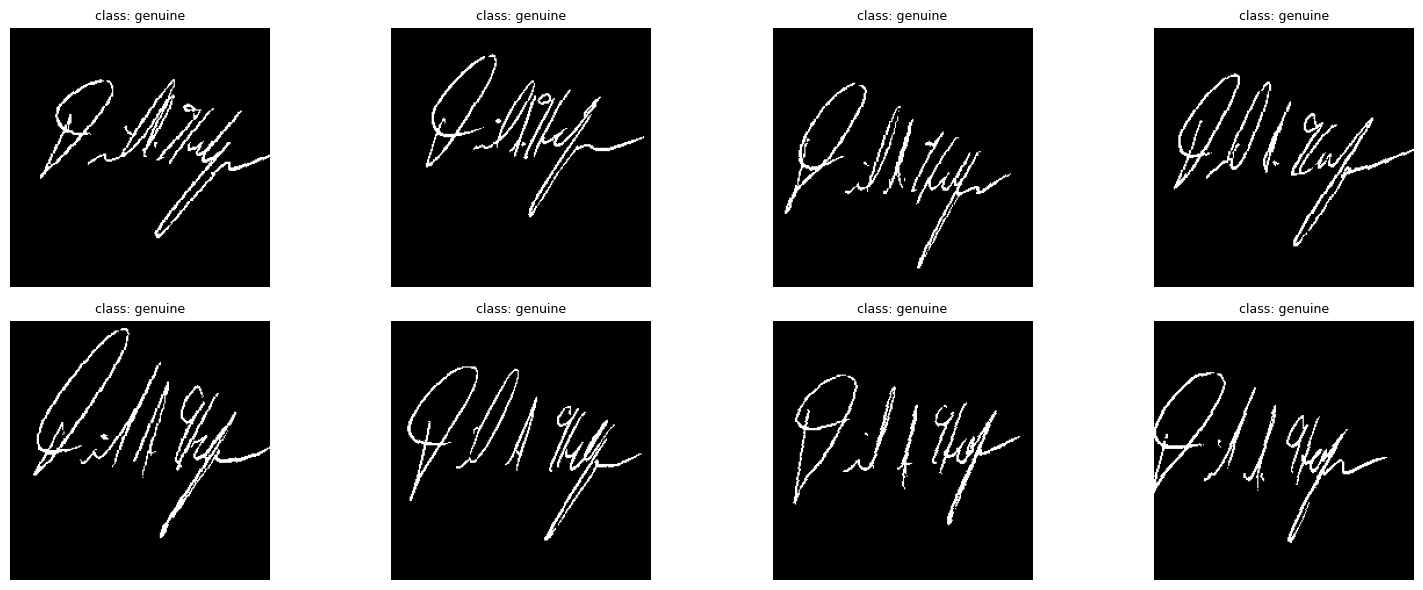

In [7]:
def show_batch(dataset, class_names, num_images=8):
    plt.figure(figsize=(16, 6))
    n = min(num_images, len(dataset))
    for i in range(n):
        img, label = dataset[i]
        arr = img.clone()
        mean = torch.tensor(NORM_MEAN).view(-1, 1, 1)
        std = torch.tensor(NORM_STD).view(-1, 1, 1)
        arr = arr * std + mean
        if arr.shape[0] == 3:
            arr = arr.mean(dim=0)
        else:
            arr = arr.squeeze(0)
        arr = arr.numpy().clip(0, 1)
        plt.subplot(2, 4, i + 1)
        plt.imshow(arr, cmap="gray")
        plt.title(f"class: {class_names[label]}", fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_dataset, class_names, num_images=8)

## Model definition

In [8]:
class SignatureCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.GroupNorm(8, out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )
        self.features = nn.Sequential(
            block(1, 32), block(32, 64), block(64, 128), block(128, 256),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.head(self.features(x))


def build_model(backbone, num_classes):
    if backbone == "custom":
        m = SignatureCNN(num_classes)
        param_groups = [{"params": m.parameters(), "lr": HEAD_LR}]
        return m, param_groups
    elif backbone == "resnet18":
        m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = m.fc.in_features
        m.fc = nn.Linear(in_features, num_classes)
        head_params = list(m.fc.parameters())
        head_ids = {id(p) for p in head_params}
        backbone_params = [p for p in m.parameters() if id(p) not in head_ids]
        param_groups = [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": HEAD_LR},
        ]
        return m, param_groups
    else:
        raise ValueError(f"Unknown backbone: {backbone}")


model, param_groups = build_model(BACKBONE, num_classes)
model = model.to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Backbone: {BACKBONE}")
print(f"Trainable parameters: {n_params:,}")

Backbone: resnet18
Trainable parameters: 11,177,538


## Loss, optimizer, scheduler

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(param_groups, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

## Training and evaluation functions

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return running_loss / len(loader.dataset), accuracy_score(all_labels, all_preds)


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return (running_loss / len(loader.dataset),
            accuracy_score(all_labels, all_preds),
            all_labels, all_preds)


def recalibrate_bn(model, loader, device, n_passes=2):
    has_bn = any(isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d))
                 for m in model.modules())
    if not has_bn:
        return
    model.train()
    with torch.no_grad():
        for _ in range(n_passes):
            for images, _ in loader:
                images = images.to(device, non_blocking=True)
                model(images)
    model.eval()

## Training loop

In [11]:
train_losses, val_losses = [], []
train_accs_loop, val_accs = [], []

best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
    scheduler.step()
    current_lr = optimizer.param_groups[-1]["lr"]

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs_loop.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch + 1:3d}/{NUM_EPOCHS} | lr={current_lr:.2e} | "
          f"train loss={train_loss:.4f} acc={train_acc:.4f} | "
          f"val loss={val_loss:.4f} acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

elapsed = time.time() - start_time
print(f"\nTraining finished in {elapsed / 60:.2f} minutes")
print(f"Best validation accuracy: {best_val_acc:.4f}")

Epoch   1/30 | lr=2.99e-04 | train loss=0.5012 acc=0.7558 | val loss=0.2883 acc=0.8873
Epoch   2/30 | lr=2.97e-04 | train loss=0.3493 acc=0.8442 | val loss=0.1987 acc=0.9327
Epoch   3/30 | lr=2.93e-04 | train loss=0.2635 acc=0.8909 | val loss=0.1545 acc=0.9400
Epoch   4/30 | lr=2.87e-04 | train loss=0.2062 acc=0.9221 | val loss=0.1446 acc=0.9455
Epoch   5/30 | lr=2.80e-04 | train loss=0.1903 acc=0.9299 | val loss=0.1008 acc=0.9709
Epoch   6/30 | lr=2.71e-04 | train loss=0.1613 acc=0.9299 | val loss=0.2085 acc=0.9164
Epoch   7/30 | lr=2.61e-04 | train loss=0.1423 acc=0.9468 | val loss=0.0994 acc=0.9564
Epoch   8/30 | lr=2.50e-04 | train loss=0.1141 acc=0.9597 | val loss=0.1196 acc=0.9509
Epoch   9/30 | lr=2.38e-04 | train loss=0.0999 acc=0.9623 | val loss=0.0999 acc=0.9600
Epoch  10/30 | lr=2.25e-04 | train loss=0.1162 acc=0.9526 | val loss=0.0756 acc=0.9709
Epoch  11/30 | lr=2.11e-04 | train loss=0.0956 acc=0.9682 | val loss=0.0532 acc=0.9836
Epoch  12/30 | lr=1.96e-04 | train loss=0.0

## Post-training sanity check

In [12]:
model.load_state_dict(best_model_wts)
recalibrate_bn(model, train_loader, device, n_passes=2)

eval_mode_train_loss, eval_mode_train_acc, _, _ = evaluate(
    model, train_eval_loader, criterion, device
)
last_loop_train_acc = train_accs_loop[-1] if train_accs_loop else float("nan")

print(f"Train accuracy (training loop, last epoch): {last_loop_train_acc:.4f}")
print(f"Train accuracy (eval mode, best checkpoint): {eval_mode_train_acc:.4f}")

gap = abs(last_loop_train_acc - eval_mode_train_acc)
if gap > 0.15 and last_loop_train_acc > eval_mode_train_acc + 0.15:
    print(f"\nWARNING: eval mode accuracy is much lower than training-loop. Gap={gap:.3f}")
else:
    print(f"Sanity check passed (gap = {gap:.3f}).")

Train accuracy (training loop, last epoch): 0.9877
Train accuracy (eval mode, best checkpoint): 1.0000
Sanity check passed (gap = 0.012).


## Final test evaluation

In [13]:
test_loss, test_acc, test_labels, test_preds = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

if num_classes <= 10:
    cm = confusion_matrix(test_labels, test_preds, labels=list(range(num_classes)))
    print("\nConfusion matrix (rows=true, cols=predicted):")
    print(cm)
    print(f"\nUnique predictions on test set: {sorted(set(test_preds))}")

    test_labels_arr = np.array(test_labels)
    test_preds_arr = np.array(test_preds)
    print("\nPer-class test accuracy:")
    for c, name in enumerate(class_names):
        mask = test_labels_arr == c
        if mask.sum() > 0:
            acc = (test_preds_arr[mask] == c).mean()
            print(f"  {name}: {acc:.4f} ({mask.sum()} samples)")

Test Loss: 0.0538
Test Accuracy: 0.9818

Confusion matrix (rows=true, cols=predicted):
[[274   1]
 [  9 266]]

Unique predictions on test set: [0, 1]

Per-class test accuracy:
  genuine: 0.9964 (275 samples)
  forgery: 0.9673 (275 samples)


## Training curves

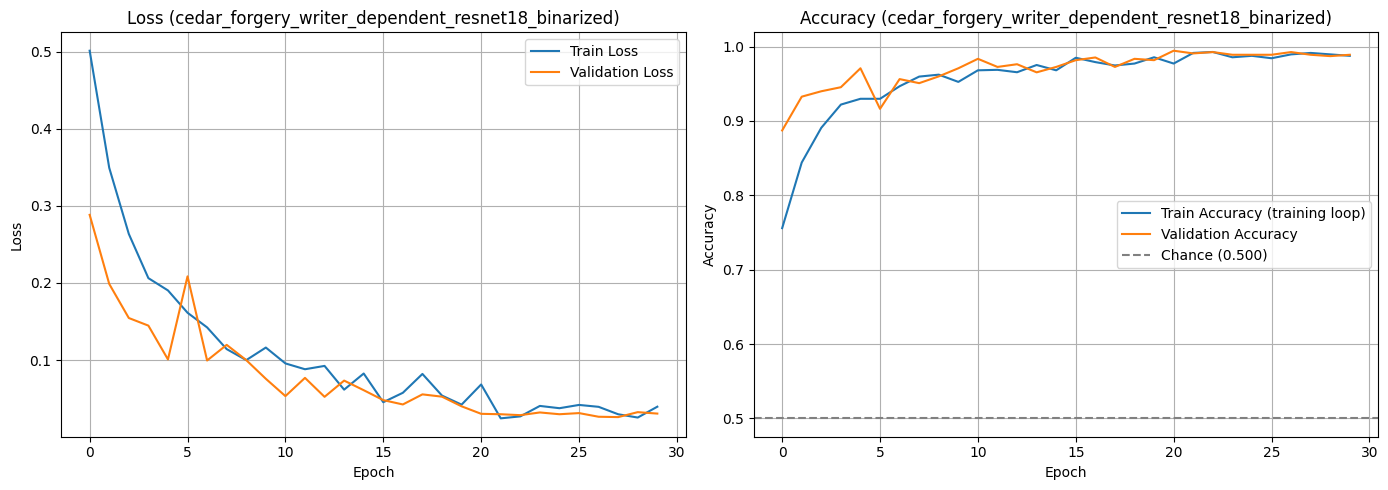

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(val_losses, label="Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title(f"Loss ({RUN_TAG})")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(train_accs_loop, label="Train Accuracy (training loop)")
axes[1].plot(val_accs, label="Validation Accuracy")
axes[1].axhline(1.0 / num_classes, color="gray", linestyle="--",
                label=f"Chance ({1.0/num_classes:.3f})")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title(f"Accuracy ({RUN_TAG})")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Summary and save

In [ ]:
# gemini helped me in mkaing this command.
chance_baseline = 1.0 / num_classes
lift = test_acc / chance_baseline

result = {
    "run_tag": RUN_TAG,
    "task": TASK,
    "backbone": BACKBONE,
    "preprocess_mode": PREPROCESS_MODE,
    "forgery_split": FORGERY_SPLIT if TASK == "forgery" else None,
    "num_classes": num_classes,
    "train_samples": len(train_dataset),
    "val_samples": len(val_dataset),
    "test_samples": len(test_dataset),
    "epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "best_val_acc": float(best_val_acc),
    "eval_mode_train_acc": float(eval_mode_train_acc),
    "test_acc": float(test_acc),
    "test_loss": float(test_loss),
    "chance_acc": float(chance_baseline),
    "lift_over_chance": float(lift),
    "train_loss_history": [float(x) for x in train_losses],
    "val_loss_history": [float(x) for x in val_losses],
    "train_acc_history": [float(x) for x in train_accs_loop],
    "val_acc_history": [float(x) for x in val_accs],
}

with open(RESULT_PATH, "w") as f:
    json.dump(result, f, indent=2)

torch.save({
    "state_dict": best_model_wts,
    "num_classes": num_classes,
    "class_names": class_names,
    "backbone": BACKBONE,
    "task": TASK,
    "preprocess_mode": PREPROCESS_MODE,
    "forgery_split": FORGERY_SPLIT if TASK == "forgery" else None,
    "image_height": IMAGE_HEIGHT,
    "image_width": IMAGE_WIDTH,
    "norm_mean": NORM_MEAN,
    "norm_std": NORM_STD,
}, CHECKPOINT_PATH)

print("========== SUMMARY ==========")
print(f"Run tag                : {RUN_TAG}")
print(f"Task                   : {TASK}")
print(f"Backbone               : {BACKBONE}")
print(f"Preprocessing          : {PREPROCESS_MODE}")
if TASK == "forgery":
    print(f"Forgery split          : {FORGERY_SPLIT}")
print(f"Number of classes      : {num_classes}")
print(f"Training samples       : {len(train_dataset)}")
print(f"Validation samples     : {len(val_dataset)}")
print(f"Test samples           : {len(test_dataset)}")
print(f"Epochs                 : {NUM_EPOCHS}")
print(f"Best validation acc    : {best_val_acc:.4f}")
print(f"Train acc (eval mode)  : {eval_mode_train_acc:.4f}")
print(f"Final test accuracy    : {test_acc:.4f}")
print(f"Final test loss        : {test_loss:.4f}")
print(f"Chance accuracy        : {chance_baseline:.4f}  (1 / {num_classes})")
print(f"Lift over chance       : {lift:.1f}x")
print(f"Saved result to        : {RESULT_PATH}")
print(f"Saved checkpoint to    : {CHECKPOINT_PATH}")
print("=============================")

NameError: name 'num_classes' is not defined

## Aggregate all CEDAR runs

In [ ]:
# Gemini gave the idea to do this.
import glob

result_files = sorted(glob.glob(str(RESULTS_DIR / "*.json")))
if not result_files:
    print("No result files found.")
else:
    print(f"Found {len(result_files)} completed run(s):\n")
    rows = []
    for path in result_files:
        with open(path) as f:
            rows.append(json.load(f))
    rows.sort(key=lambda r: (r["task"], r.get("forgery_split") or "",
                             r["backbone"], r.get("preprocess_mode") or ""))

    header = (f"{'run_tag':<55s} {'task':>9s} {'classes':>8s} "
              f"{'test_acc':>10s} {'val_acc':>10s} {'lift':>8s}")
    print(header)
    print("-" * len(header))
    for r in rows:
        print(f"{r['run_tag']:<55s} {r['task']:>9s} {r['num_classes']:>8d} "
              f"{r['test_acc']:>10.4f} {r['best_val_acc']:>10.4f} "
              f"{r['lift_over_chance']:>7.1f}x")

Found 10 completed run(s):

run_tag                                                      task  classes   test_acc    val_acc     lift
---------------------------------------------------------------------------------------------------------
cedar_forgery_custom                                      forgery        2     0.5618     0.6055     1.1x
cedar_forgery_resnet18                                    forgery        2     1.0000     1.0000     2.0x
cedar_forgery_writer_dependent_resnet18_binarized         forgery        2     0.9818     0.9945     2.0x
cedar_forgery_writer_independent_resnet18_binarized       forgery        2     0.6687     0.9933     1.3x
cedar_writer_10_custom                                     writer       10     0.8800     0.9400     8.8x
cedar_writer_2_custom                                      writer        2     1.0000     1.0000     2.0x
cedar_writer_all_custom                                    writer       55     0.8945     0.9127    49.2x
cedar_writer_10_re